# InterScale Pipeline: Combined model

1. Local Model = GCN
2. Global Model = Self-attention transformer

Data: Legnini et. al. 

In [2]:
import scanpy as sc
import numpy as np
import squidpy as sq

import InterScale as interscale
from InterScale.config import load_config
from InterScale.tl import prepare_geome_dataset, check_and_update_cfg
from InterScale.geome_dataloader import GraphAnnDataModule

from sklearn.preprocessing import label_binarize

In [3]:
CFG_PATH_CLAS = "/dss/dsshome1/05/di93tig/1_projects/GT-long-range-niches/src/config_files/Legnini23/legnini23_class_graph_Combined_condition.yaml"

## 0. Load and prepare data

We load a subset of the CosmX pancreas data containing T1D (type 1 diabetes) and ND (no diabetes) samples and the config file with the model specifications. 

In [4]:
cfg = load_config(CFG_PATH_CLAS)
cfg

CfgNode({'wandb': CfgNode({'use': True, 'project_name': 'GTLongRange_Legnini23'}), 'model': CfgNode({'n_embed': 16, 'local_component': CfgNode({'name': 'GCN', 'load': None, 'parameters': CfgNode({'hidden_dim': 256, 'num_layers': 2, 'dropout_local': 0.1})}), 'global_component': CfgNode({'name': 'self-attn-transformer', 'load': None, 'parameters': CfgNode({'n_heads': 4, 'dim_feedforward': 256, 'dropout_global': 0.1, 'activation_func': 'relu', 'num_layers': 2, 'max_seq_len': 4299, 'long_range_attention': True})}), 'save': '/dss/dssfs03/tumdss/pn36po/pn36po-dss-0002/di93tig/Projects/A3_InterScale/results/legnini23/', 'loss': None, 'decoder': CfgNode({'type': 'linear', 'hidden_dims': [256, 128], 'dropout_decoder': 0.1})}), 'optim': CfgNode({'lr': 0.001, 'lr_scheduler': 'CosineWarmupScheduler', 'lr_warmup': 20, 'lr_max_epochs': 100, 'wd': 0.0001, 'loss': 'CrossEntropy', 'seed': 44, 'cross_corr': 'cell', 'n_epochs': 100, 'early_stopping': True}), 'dataset': CfgNode({'h5ad_data': '/dss/dssfs03

In [5]:
adata = sc.read_h5ad(cfg.dataset.h5ad_data)
adata

AnnData object with n_obs × n_vars = 43762 × 88
    obs: 'Cell', 'Area', 'x', 'y', 'sample', 'condition', 'organoid', 'obs_names', 'split'
    var: 'gene_ids', 'feature_types'
    obsm: 'spatial'
    layers: 'log1p_norm', 'norm_ftsqrt', 'raw'

Remove cells with zero expression across all genes. Gives error for pearson correlation.

In [6]:
zero_expression_cells = np.array((adata.X.sum(axis=1) == 0)).flatten()
print(f"Nr. of zero expression cells: {zero_expression_cells.sum()}")
nonzero_cells = np.array((adata.X.sum(axis=1) != 0)).flatten()
adata = adata[nonzero_cells].copy()

Nr. of zero expression cells: 648


In [7]:
import pandas as pd
# Creating a DataFrame from 'split', 'fov', and 'condition'
df = adata.obs[['split', 'sample', 'condition']]
value_counts = pd.DataFrame(df.values, columns=df.columns).value_counts()
print(value_counts)

split  sample       condition
train  slide1_D2-2  SHH          4299
       slide1_D2-3  SHH          3516
       slide1_C2-2  SHH          3350
val    slide1_B2-1  SHH          3284
train  slide4_B2-1  SHH          3175
       slide1_A2-1  SHH          3023
       slide1_C2-1  Ctrl         2870
       slide4_A2-1  SHH          2626
       slide4_A2-2  SHH          2505
val    slide1_B2-3  SHH          2134
test   slide4_A2-3  Ctrl         1983
train  slide1_C2-5  Ctrl         1938
test   slide4_B2-2  SHH          1772
train  slide1_B2-2  Ctrl         1699
val    slide1_A2-2  SHH          1691
       slide1_C2-3  Ctrl         1627
       slide4_B2-3  Ctrl         1622
Name: count, dtype: int64


## 1. Data setup

We need to specify:

- `prediction_task`: Prediction task can either be classification or regression
- `prediction_level`: Which level the predictions should be performed on: either (1) tissue label, e.i. condition (`graph`), (2) node label (`node`) for cell type or niche prediciton, or (3) GEX prediction.

Additionally, we define dataset specific keys: 
- `prediction_obs`: Label in `adata.obs` to be predicted. Only required for classification tasks.
- `layer_key`: Defines which GEX matrix to retrieve from `adata.layer`
- `sample_key`: `adata.obs` used to split the samples into PyG Data objects
- `group_label`: Optional: only if we have a `adata.obs` group that we want to stratify during sampling

In [8]:
PREDICTION_TASK = 'classification'
PREDICTION_LEVEL = 'graph'

prediction_obs = 'condition'
layer_key = 'log1p_norm'
sample_key = ['sample']
group_label = 'condition'

In [9]:
cfg = check_and_update_cfg(cfg, prediction_task = PREDICTION_TASK, prediction_level = PREDICTION_LEVEL, layer_key = layer_key, sample_key = sample_key, prediction_obs = prediction_obs)

Update prediction obs (from 'None' to 'condition')
Update sample key (from '['sample']' to '['sample']')
Update group label (from 'condition' to 'None')


In [10]:
interscale.model.CombinedModel._setup_anndata(adata = adata, prediction_task = PREDICTION_TASK, layer_key = layer_key, sample_key_list = sample_key, prediction_obs = prediction_obs, group_key = group_label)

/usr/local/lib/python3.10/dist-packages/scvi/data/fields/_base_field.py:63: UserWarning: adata.layers[log1p_norm] does not contain unnormalized count data. Are you sure this is what you want?
  self.validate_field(adata)


Anndata setup with scvi-tools version 1.3.2.

     Summary Statistics     
┏━━━━━━━━━━━━━━━━━━┳━━━━━━━┓
┃ Summary Stat Key ┃ Value ┃
┡━━━━━━━━━━━━━━━━━━╇━━━━━━━┩
│   n_group_key    │   2   │
│ n_prediction_obs │   2   │
│  n_sample_key_0  │  17   │
│       n_x        │  88   │
└──────────────────┴───────┘

                    Data Registry                     
┏━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃  Registry Key  ┃        scvi-tools Location        ┃
┡━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│   group_key    │   adata.obs['_scvi_group_key']    │
│ prediction_obs │ adata.obs['_scvi_prediction_obs'] │
│  sample_key_0  │  adata.obs['_scvi_sample_key_0']  │
│       x        │    adata.layers['log1p_norm']     │
└────────────────┴───────────────────────────────────┘

                sample_key_0 State Registry                
┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃   Source Location   ┃ Categories  ┃ scvi-tools Encoding ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ adata.obs['sample'] │ slide1_A2-1 │          0          │
│                     │ slide1_A2-2 │          1          │
│                     │ slide1_B2-1 │          2          │
│                     │ slide1_B2-2 │          3          │
│                     │ slide1_B2-3 │          4          │
│                     │ slide1_C2-1 │          5          │
│                     │ slide1_C2-2 │          6          │
│                     │ slide1_C2-3 │          7          │
│                     │ slide1_C2-5 │          8          │
│                     │ slide1_D2-2 │          9          │
│                     │ slide1_D2-3 │         10          │
│                     │ slide4_A2-1 │         11          │
│                     │ slide4_A2-2 │         12          │
│                     │ slide4_A2-3 │         13          │
│                     │ slide4_B2-1 │         14          │
│                     │ slide4_B2-2 │         15          │
│                     │ slide4_B2-3 │         16          │
└─────────────────────┴─────────────┴─────────────────────┘

                prediction_obs State Registry                
┏━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃    Source Location     ┃ Categories ┃ scvi-tools Encoding ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ adata.obs['condition'] │    Ctrl    │          0          │
│                        │    SHH     │          1          │
└────────────────────────┴────────────┴─────────────────────┘

                  group_key State Registry                   
┏━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃    Source Location     ┃ Categories ┃ scvi-tools Encoding ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ adata.obs['condition'] │    Ctrl    │          0          │
│                        │    SHH     │          1          │
└────────────────────────┴────────────┴─────────────────────┘

## 2. Model setup

In [11]:
model = interscale.model.CombinedModel(
    adata,
    cfg = cfg
)


/usr/local/lib/python3.10/dist-packages/torch/nn/modules/transformer.py:379: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


In [12]:
model._model_summary_string

'classification model for graph prediction. \nCombined Module: \nLocal Module: GCN Local Component: \nn_layers: 2, \nn_hidden: 256, \nn_embed: 16, \ndropout_local: 0.1\nGlobal Module: Transformer Encoder Global Component: \nmax_seq_len: 4299, \nn_heads: 4, \nact_func: relu, \nnum_layers: 2, \n\n'

## 3. Training

In [13]:
#split_adata(adata, split_obs='sample', val_size=cfg.dataset.val_size, test_size=cfg.dataset.test_size, seed = cfg.optim.seed, stratify_groups = cfg.dataset.group_label)
pyg_data_list, _ = prepare_geome_dataset(adata, cfg)
dm = GraphAnnDataModule(datas=pyg_data_list, 
                           num_workers=1, 
                           batch_size=int(cfg.dataset.batch_size), 
                           pct_mask_nodes=cfg.dataset.pct_mask_nodes,
                           learning_type="node")

Split key split already exists in adata.obs
call new
{'condition': ['Ctrl', 'SHH']}


/usr/local/lib/python3.10/dist-packages/geome/transforms/categorize.py:38: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  getattr(adata, self.axis)[key] = getattr(adata, self.axis)[key].astype("category")


call new
{'condition': ['Ctrl', 'SHH']}


/usr/local/lib/python3.10/dist-packages/geome/transforms/categorize.py:38: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  getattr(adata, self.axis)[key] = getattr(adata, self.axis)[key].astype("category")


call new
{'condition': ['Ctrl', 'SHH']}
call new
{'condition': ['Ctrl', 'SHH']}


/usr/local/lib/python3.10/dist-packages/geome/transforms/categorize.py:38: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  getattr(adata, self.axis)[key] = getattr(adata, self.axis)[key].astype("category")
/usr/local/lib/python3.10/dist-packages/geome/transforms/categorize.py:38: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  getattr(adata, self.axis)[key] = getattr(adata, self.axis)[key].astype("category")


In [14]:
# import os
# # Remove SLURM environment variables that Lightning is detecting
# for key in list(os.environ.keys()):
#     if key.startswith('SLURM'):
#         del os.environ[key]

In [15]:
model.train(max_epochs = 20, 
           datamodule = dm,
           early_stopping = True,
           batch_size = int(cfg.dataset.batch_size),
           train_size = float(cfg.dataset.train_size),
           validation_size = float(cfg.dataset.val_size),
           wandb_use = False)

[rank: 0] Seed set to 44
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/usr/local/lib/python3.10/dist-packages/lightning/pytorch/callbacks/model_checkpoint.py:658: Checkpoint directory /dss/dssfs03/tumdss/pn36po/pn36po-dss-0002/di93tig/Projects/A3_InterScale/results/legnini23 exists and is not empty.

  | Name          | Type                | Params | Mode 
--------------------------------------------------------------
0 | module        | CombinedModuleClass | 46.3 K | train
1 | loss          | CrossEntropyLoss    | 0      | train
2 | train_metrics | MetricCollection    | 0      | train
3 | valid_metrics | MetricCollection    | 0      | train
4 | test_metrics  | MetricCollection    | 0      | train
--------------------------------------------------------------
46.3 K    Trainable params
0         Non-trainable params
46.3 K    Total params
0.185     Total estimated model params size (MB)
56        Modules in train mode
0 

Steps per epoch 4
batch_mask: tensor([[0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        ...,
        [0., 0., 0.,  ..., 0., 1., 0.],
        [0., 0., 0.,  ..., 1., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.]])
batch_mask: tensor([[0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        ...,
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.]])
batch_mask: tensor([[0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        ...,
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.]])
batch_mask: tensor([[0., 0., 1.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [1., 0., 0.,  ..., 0., 0., 0.],
        ...,
        [0., 0., 0.,  ..., 0., 0., 0.],

SLURM auto-requeueing enabled. Setting signal handlers.


batch_mask: tensor([[0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        ...,
        [0., 0., 0.,  ..., 0., 1., 0.],
        [0., 0., 0.,  ..., 1., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.]])
batch_mask: tensor([[0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        ...,
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.]])
batch_mask: tensor([[0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        ...,
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.]])
batch_mask: tensor([[0., 0., 1.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [1., 0., 0.,  ..., 0., 0., 0.],
        ...,
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃      Validate metric      ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│       val_accuracy        │            0.5            │
│        val_f1_Ctrl        │            0.5            │
│        val_f1_SHH         │            0.0            │
│       val_f1_macro        │            0.5            │
│       val_f1_micro        │            0.5            │
│         val_loss          │            nan            │
└───────────────────────────┴───────────────────────────┘

SLURM auto-requeueing enabled. Setting signal handlers.


batch_mask: tensor([[0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 1.,  ..., 0., 0., 0.],
        [0., 1., 0.,  ..., 0., 0., 0.],
        ...,
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.]])
batch_mask: tensor([[0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 1.,  ..., 0., 0., 0.],
        [0., 1., 0.,  ..., 0., 0., 0.],
        ...,
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.]])


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│       test_accuracy       │            0.5            │
│       test_f1_Ctrl        │    0.6666666865348816     │
│        test_f1_SHH        │            0.0            │
│       test_f1_macro       │    0.3333333432674408     │
│       test_f1_micro       │            0.5            │
│         test_loss         │            nan            │
└───────────────────────────┴───────────────────────────┘

Model checkpoint will be saved in:  /dss/dssfs03/tumdss/pn36po/pn36po-dss-0002/di93tig/Projects/A3_InterScale/results/legnini23/legnini23_clas_graph_GCN_self-attn-transformer_model.ckpt


/dss/dsshome1/05/di93tig/1_projects/GT-long-range-niches/src/InterScale/train/_training.py:229: UserWarning: File /dss/dssfs03/tumdss/pn36po/pn36po-dss-0002/di93tig/Projects/A3_InterScale/results/legnini23/legnini23_clas_graph_GCN_self-attn-transformer_model.pt already exists. Set overwrite=True to overwrite.
  self.save(self._cfg.model.save)


In [18]:
model.history_.history

[{'lr-AdamW': 9.999999747378752e-06,
  'val_accuracy': 0.5,
  'val_f1_macro': 0.5,
  'val_f1_micro': 0.5,
  'val_loss': nan,
  'val_f1_Ctrl': 0.5,
  'val_f1_SHH': 0.0,
  'train_accuracy': 0.3333333432674408,
  'train_f1_macro': 0.2666666805744171,
  'train_f1_micro': 0.3333333432674408,
  'train_loss': nan,
  'train_f1_Ctrl': 0.36666667461395264,
  'train_f1_SHH': 0.1666666716337204,
  'epoch': 0}]

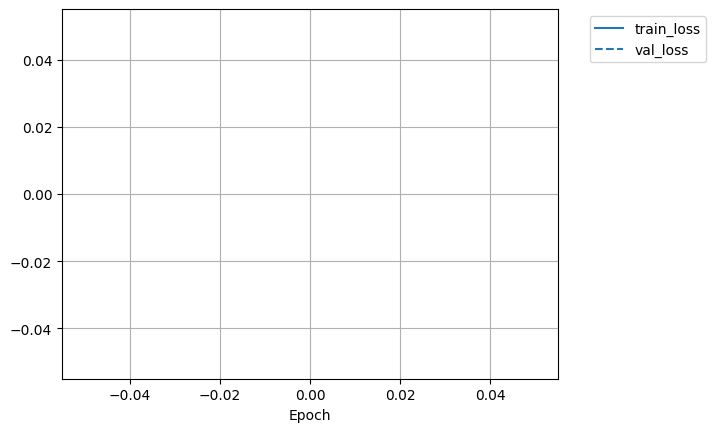

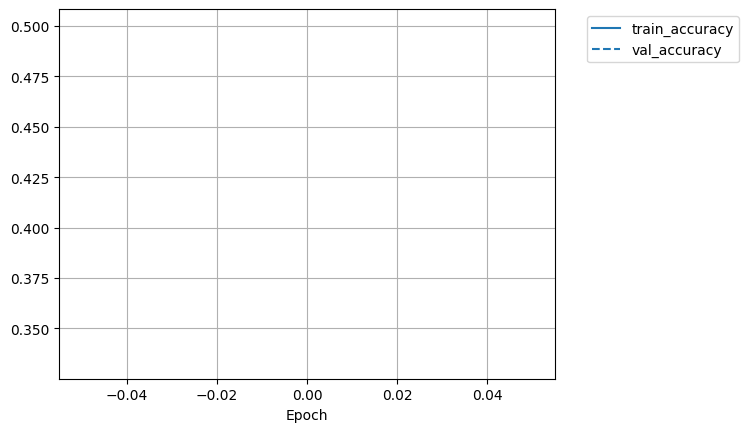

In [17]:
model.history_.plot_history(subset_term = 'loss')
model.history_.plot_history(subset_term = 'accuracy')

# model.history_.plot_history(subset_term = 'loss')
# model.history_.plot_history(subset_term = 'r2')
# model.history_.plot_history(subset_term = 'pearson')

## 4. Evaluation

Evaluation can either be run on the entire AnnData that the model was set up with or subsets of AnnData defined by sample_id from `adata.obs[sample_key]`.

In [35]:
#sub_adata = adata[adata.obs['condition'] == 'SHH']

In [36]:
result = model.get_model_output(adata)

Load GEX from .layers/log1p_norm
call new
{'condition': ['Ctrl', 'SHH']}
3024
1692
3285
1700
2135
2871
3351
1628
1939
4300
3517
2627
2506
1984
3176
1773
1623


### 4.1 Tissue level analysis

Can we detect a pattern across cells in which are more and less relevant to predict the condition? 

No cell types so need to categorize them differently. 

1. SHH expressed or not (Distance to SHH source)
2. What analysis could we perform without knowing that the SHH is the source for variation? Can we somehow trace the changes back to genes? 

In [37]:
np.unique(result.obs['sample'][result.obs['split']== 'test'])

array(['slide4_A2-3', 'slide4_B2-2'], dtype=object)

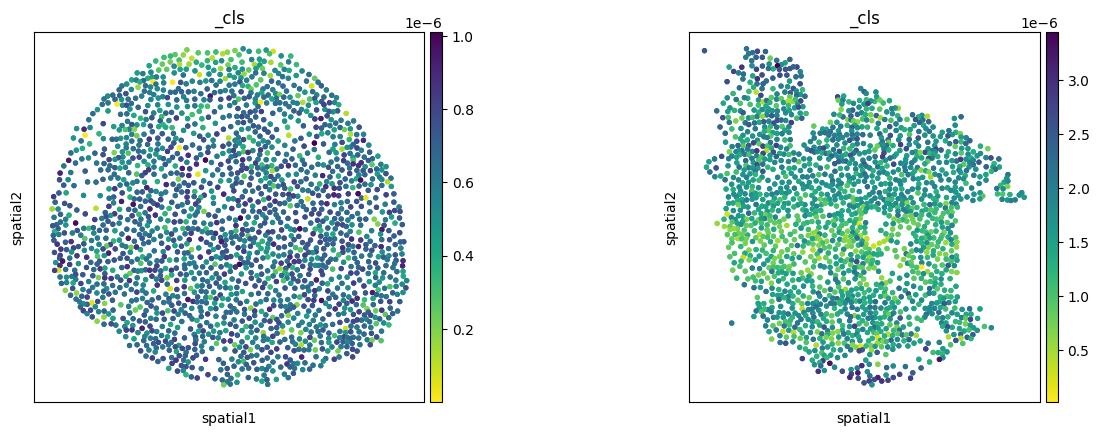

In [40]:
sq.pl.spatial_scatter(result[result.obs['split'] == 'test'], 
                      color = ['_cls'],
                      library_key = 'sample',
                    cmap = 'viridis_r',
                    shape= None,
                    #save = f'{FIG_PATH}/legnini23/legnini23_log1p_ctrl_{sample_ctrl}_SHH.jpeg'
)

In [45]:
#TODO use slide dependent threshold
cls_threshold = result.obs['_cls'][result.obs['split'] == 'test'].median()
adata.obs['cls_cluster'] = 'low'
adata.obs.loc[adata.obs['_cls'] > cls_threshold, 'cls_cluster'] = 'high'

/usr/local/lib/python3.10/dist-packages/anndata/_core/anndata.py:1138: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/usr/local/lib/python3.10/dist-packages/squidpy/pl/_spatial_utils.py:976: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(
/usr/local/lib/python3.10/dist-packages/squidpy/pl/_spatial_utils.py:976: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(


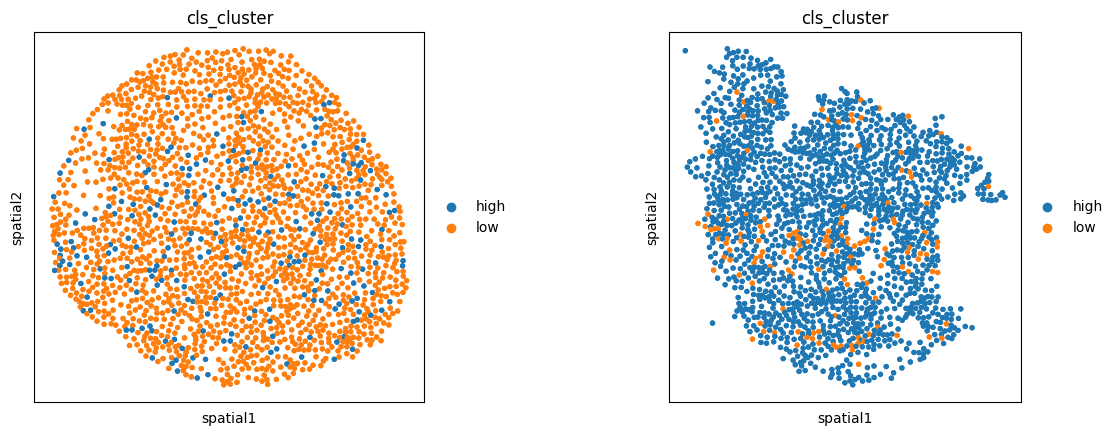

In [47]:
sq.pl.spatial_scatter(result[result.obs['split'] == 'test'], 
                      color = ['cls_cluster'],
                      library_key = 'sample',
                    cmap = 'viridis_r',
                    shape= None,
                    #save = f'{FIG_PATH}/legnini23/legnini23_log1p_ctrl_{sample_ctrl}_SHH.jpeg'
)

/usr/local/lib/python3.10/dist-packages/numpy/core/fromnumeric.py:86: FutureWarning: The behavior of DataFrame.sum with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return reduction(axis=axis, out=out, **passkwargs)


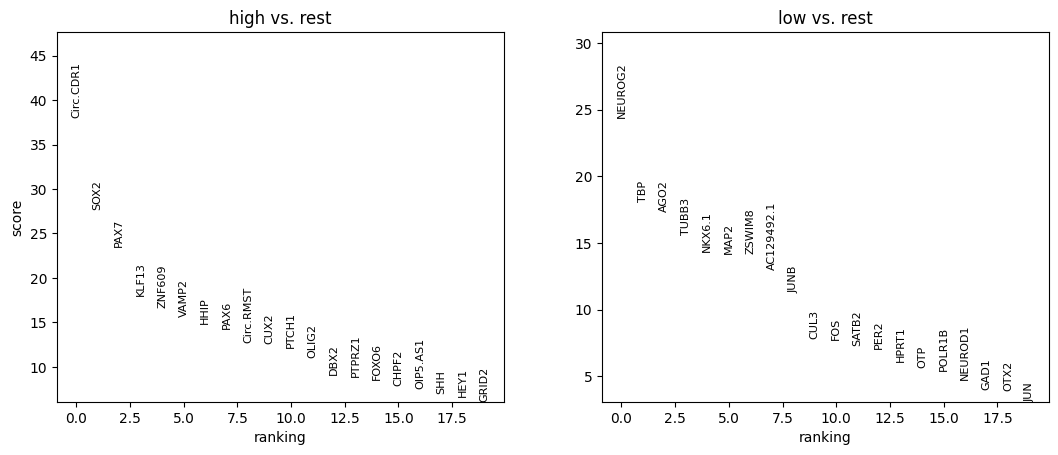

        names     scores  logfoldchanges          pvals      pvals_adj
0   Circ.CDR1  38.053070        8.224084   0.000000e+00   0.000000e+00
1        SOX2  27.716837        3.732658  4.376378e-169  1.925606e-167
2        PAX7  23.461014        2.175617  1.020482e-121  2.245061e-120
3       KLF13  17.989428        0.508371   2.357771e-72   3.458063e-71
4      ZNF609  16.601700        1.036182   6.774564e-62   7.452020e-61
5       VAMP2  15.656178        0.590351   3.014780e-55   2.947785e-54
6        HHIP  14.884706        0.688784   4.143076e-50   3.314461e-49
7        PAX6  14.274787        1.567083   3.142480e-46   2.127217e-45
8   Circ.RMST  12.655084        2.542598   1.048643e-36   5.428268e-36
9        CUX2  12.633532        0.331259   1.379453e-36   6.743990e-36
10      PTCH1  12.109941        1.404517   9.356056e-34   4.333331e-33
11      OLIG2  11.017069        1.007339   3.161872e-28   1.324975e-27
12       DBX2   9.113412        0.249441   7.983071e-20   3.193228e-19
13    

/dss/dsshome1/05/di93tig/.local/lib/python3.10/site-packages/scanpy/get/get.py:69: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  d = d.stack(level=1).reset_index()


In [48]:
import scanpy as sc

# Option 1: Using scanpy's rank_genes_groups (recommended)
sc.tl.rank_genes_groups(adata, groupby='cls_cluster', method='wilcoxon', key_added='cls_cluster_de')

# View top genes
sc.pl.rank_genes_groups(adata, n_genes=20, key='cls_cluster_de', sharey=False)

# Get results as DataFrame
result = sc.get.rank_genes_groups_df(adata, group='high', key='cls_cluster_de')
print(result.head(20))

In [39]:
adata.obs['sample'][adata.obs['split']== 'test']

34563    slide4_A2-3
34564    slide4_A2-3
34565    slide4_A2-3
34566    slide4_A2-3
34567    slide4_A2-3
            ...     
41488    slide4_B2-2
41489    slide4_B2-2
41490    slide4_B2-2
41491    slide4_B2-2
41492    slide4_B2-2
Name: sample, Length: 3755, dtype: category
Categories (17, object): ['slide1_A2-1', 'slide1_A2-2', 'slide1_B2-1', 'slide1_B2-2', ..., 'slide4_A2-3', 'slide4_B2-1', 'slide4_B2-2', 'slide4_B2-3']

In [ ]:
# Cluster conditions
result.obs['cls_cluster'] = 'low'
result.obs['cls_cluster'] = 'high'[result.obs['_cls'] > ???]

### CLS token to predict the conditions

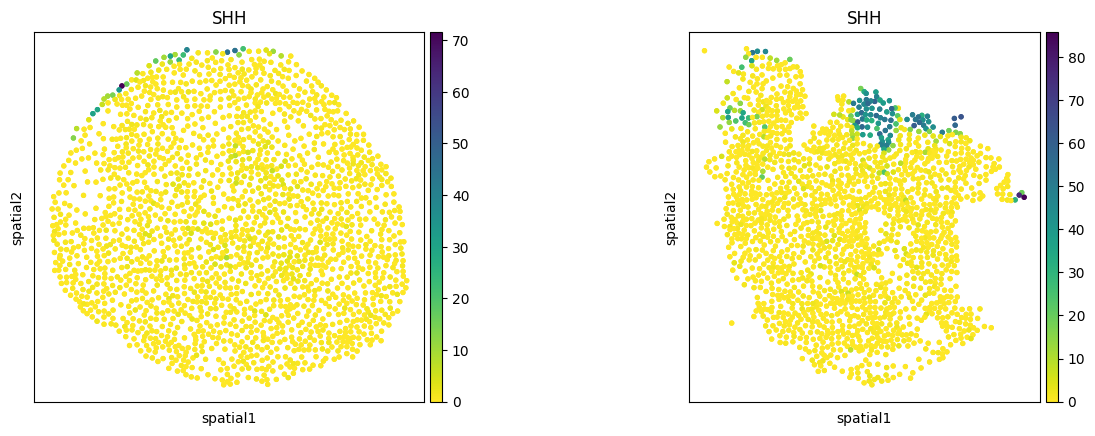

In [46]:
sq.pl.spatial_scatter(result[result.obs['split'] == 'test'], 
                      color = ['SHH'],
                      library_key = 'sample',
                    cmap = 'viridis_r',
                    shape= None,
                    #save = f'{FIG_PATH}/legnini23/legnini23_log1p_ctrl_{sample_ctrl}_SHH.jpeg'
)

In [24]:
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

# Step 1: Prepare data
X_all = np.vstack(result.obs['_cls'].values)
y_all = result.obs['condition'].values
samples_all = result.obs['sample'].values

# Drop samples with NaNs
mask = ~np.isnan(X_all).any(axis=1)
X = X_all[mask]
y = y_all[mask]
samples = samples_all[mask]

# Standardize features
X = StandardScaler().fit_transform(X)

# Step 2: Fit classifier
clf = LogisticRegression(max_iter=1000)
clf.fit(X, y)

# Step 3: Predict and evaluate
y_pred = clf.predict(X)
accuracy = accuracy_score(y, y_pred)
print(f"Accuracy: {accuracy:.3f}")

# Step 4: Save predictions and correctness into adata.obs
adata.obs.loc[mask, 'predicted_condition'] = y_pred
adata.obs.loc[mask, 'correct_prediction'] = (y_pred == y).astype(str)  # "True"/"False" for plotting


ValueError: This solver needs samples of at least 2 classes in the data, but the data contains only one class: 'SHH'

ValueError: 'color' kwarg must be a color or sequence of color specs.  For a sequence of values to be color-mapped, use the 'c' argument instead.

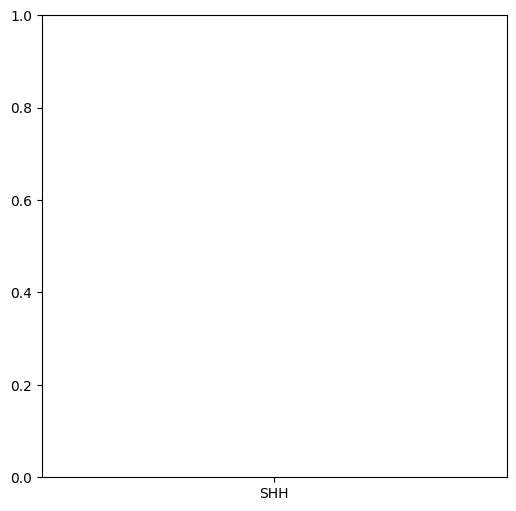

In [91]:
import matplotlib.pyplot as plt

# Suppose you have:
# coords: an (N, 2) array or DataFrame with columns ['x', 'y']
# values: a 1D array or Series with length N (values to color by)

plt.figure(figsize=(6,6))
sc = plt.scatter(y, X, color = samples, s=40)
plt.colorbar(sc, label='Value')
plt.xlabel('X coordinate')
plt.ylabel('Y coordinate')
plt.title('Spatial plot colored by 1D values')
plt.gca().invert_yaxis()  # if you want y-axis inverted (depends on data)
plt.show()


In [43]:
# plot celltype x condition 
import pandas as pd

def summarise_decoder_weight_by_group_and_condition(
    adata, 
    group_obs: str,
    condition_obs: str = '_scvi_prediction_obs', 
    decoder_weight_key: str = 'decoder_weight', 
):
    """
    Summarizes average attention weights for each (group_obs x condition_obs) combination.
    
    Parameters
    ----------
    adata : AnnData
        AnnData object containing attention weights in adata.obsm[decoder_weight_key].
    decoder_weight_key : str
        Key for the attention weight matrix in adata.obsm.
    condition_obs : str
        Column name in adata.obs for condition (e.g., 'disease_status').
    group_obs : str
        Column name in adata.obs for group (e.g., 'cell_type').
        
    Returns
    -------
    pd.DataFrame
        Multi-index DataFrame with average attention weights for each group x condition.
        Rows: (group_obs, condition_obs)
        Columns: attention per target cell type (from decoder_weight_key).
    """
    # Extract relevant data
    weight = adata.obsm[decoder_weight_key]
    group = adata.obs[group_obs]
    condition = adata.obs[condition_obs]
    
    # Create DataFrame for easy grouping
    df = pd.DataFrame(
        weight, 
        columns=[f"{decoder_weight_key}_{i}" for i in range(weight.shape[1])]
    )
    df[group_obs] = group.values
    df[condition_obs] = condition.values
    
    # Group by group_obs and condition_obs, then average
    grouped = df.groupby([group_obs, condition_obs]).mean()
    
    return grouped

In [44]:
summarise_decoder_weight_by_group_and_condition(
    result, 
    condition_obs = 'shh_cluster', 
    group_obs = 'condition'
)

KeyError: 'shh_cluster'

In [ ]:
from scipy.stats import pearsonr
import torch
import numpy as np

y_pred_np = torch.tensor([[0.1, 0.2, 0.3],
                         [0.15, 0.25, 0.35]])
y_true_np = torch.tensor([[0.0, 0.4, 0.6],
                        [0.0, 0.34, 0.43]])

pearson_corr_raw = pearsonr(y_pred_np, y_true_np)
pearson_corr = torch.tensor(np.nanmean(pearson_corr_raw[0]), 
                                      dtype=torch.float32, 
                                      device=y_pred_np.device)

In [ ]:
pearson_corr

In [ ]:
pearson_corr_raw